In [1]:
import os
os.chdir('../../../../../..')

In [2]:
import numpy as np
import hdbscan
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
import gc
import numpy as np
import polars as pl
from dscribe.descriptors import SOAP
from rdkit import Chem
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import polars as pl
from ase import Atoms
from dscribe.descriptors import SOAP
from rdkit import Chem
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split




from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from umap import UMAP
from dscribe.kernels import REMatchKernel

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid, get_isomers

projection_method = "MDS"

In [3]:
qm9 = QM9Dataset(limit=10_000)
df = qm9.load()

2026-05-20 11:55:35.215 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-20 11:55:35.649 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=10000, returned_rows=10000, sampling on columns=['num_atoms', 'gap'].


In [4]:
def remove_explicit_hydrogens(smiles: str) -> str:
    if smiles is None:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol_no_h = Chem.RemoveHs(mol)
    return Chem.MolToSmiles(mol_no_h)
df = df.with_columns(
    pl.col("smiles")
    .map_elements(remove_explicit_hydrogens, return_dtype=pl.String)
    .alias("smiles") 
)

# Hypothesis 1
- Goal is to tell a story of how SOAP improves on some of the flaws that morgan fingerprint has.



In [5]:
def generate_soap_features(
    df: pl.DataFrame,
    r_cut: float = 4.5,
    n_max: int = 8,
    l_max: int = 6,
    sigma: float = 0.5,
    crossover: bool = True,
) -> pl.DataFrame:
    """Generates species-resolved, averaged SOAP molecular embeddings from a Polars

    DataFrame containing 'atomic_numbers' and 'coordinates'.
    """
    # 1. Define the complete chemical space of your dataset (QM9 baseline)
    all_species = ["H", "C", "N", "O", "F"]

    # 2. Initialize the tunable DScribe SOAP engine
    soap_engine = SOAP(
        species=all_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        sparse=False,
    )

    # Pre-calculate the feature size per atom for zero-padding missing elements
    num_features_per_atom = soap_engine.get_number_of_features()

    def process_row(atomic_numbers, coordinates):
        """Worker function that processes a single molecule's geometry row."""
        if atomic_numbers is None or coordinates is None:
            return None

        # Convert atomic numbers to chemical symbols
        symbols = [Chem.Atom(int(z)).GetSymbol() for z in atomic_numbers]
        positions = np.array(coordinates)

        # Build native ASE Atoms object to satisfy DScribe's geometry requirements
        try:
            system = Atoms(symbols=symbols, positions=positions)
        except Exception:
            return None

        # Compute the atomic descriptor matrix: Shape (num_atoms, num_features_per_atom)
        try:
            atomic_soap = soap_engine.create(system)
        except Exception:
            return None

        # Species-specific pooling loop
        # Ensures every molecule yields an identically structured 1D feature array
        molecular_segments = []
        for element in all_species:
            # Find indices belonging to this element type
            indices = [i for i, sym in enumerate(symbols) if sym == element]

            if indices:
                # Average only across environments of this specific element type
                element_mean = np.mean(atomic_soap[indices], axis=0)
                molecular_segments.append(element_mean)
            else:
                # If the element isn't present, fill its slot with zeros
                molecular_segments.append(np.zeros(num_features_per_atom))

        # Concatenate all element blocks into a single flat molecular vector
        return np.concatenate(molecular_segments).tolist()

    print(
        f"Computing SOAP (rcut={r_cut}, nmax={n_max}, lmax={l_max}, elements={len(all_species)})..."
    )

    # 3. Execute row-by-row using Polars struct mapping
    return df.with_columns(
        pl.struct(["atomic_numbers", "coordinates"])
        .map_elements(
            lambda row: process_row(row["atomic_numbers"], row["coordinates"]),
            return_dtype=pl.List(pl.Float64),
        )
        .alias("soap_embedding")
    )

#df_with_soap = generate_soap_features(df)

def generate_morgan_features(
    df: pl.DataFrame,
    radius: int = 2,
    n_bits: int = 2048,
    use_counts: bool = True,
) -> pl.DataFrame:
    """Generates tunable Morgan Fingerprint arrays from a SMILES column."""

    def process_smiles(smiles):
        if smiles is None:
            return None

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        mol = Chem.RemoveHs(mol)

        if use_counts:
            # FIXED: Use GetMorganFingerprint for count/sparse representations
            fp = AllChem.GetMorganFingerprint(mol, radius=radius)
            arr = np.zeros((n_bits,), dtype=np.int32)
            # Fold arbitrary sparse fragment keys into the fixed bit bucket array
            for idx, count in fp.GetNonzeroElements().items():
                arr[idx % n_bits] += count
        else:
            # Traditional binary bit array layout
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            arr = np.zeros((1,), dtype=np.int32)
            Chem.DataStructs.ConvertToNumpyArray(fp, arr)

        return arr.tolist()

    print(
        f"Computing Morgan Fingerprints (radius={radius}, n_bits={n_bits}, counts={use_counts})..."
    )

    return df.with_columns(
        pl.col("smiles")
        .map_elements(process_smiles, return_dtype=pl.List(pl.Int32))
        .alias("morgan_fingerprint")
    )

#df_with_morgan = generate_morgan_features(df_with_soap)

In [14]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
indices = np.arange(df.height)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
y_train = df["mu"].to_numpy()[train_idx]
y_test = df["mu"].to_numpy()[test_idx]

def evaluate_representation_safely(df_processed, feature_col, name):
    """Extracts, handles a non-linear hyperparameter grid search across 10 combinations

    of alpha/gamma, and flushes matrices from RAM.
    """
    # 1. Isolate target array
    y_full = df_processed["mu"].to_numpy()

    # 2. Extract and stack features locally
    print(f" -> Stacking {name} matrix in memory...")
    X_matrix = np.vstack(df_processed[feature_col].to_list())

    # 3. Splits
    indices = np.arange(len(y_full))
    train_idx, test_idx = train_test_split(
        indices, test_size=0.2, random_state=42
    )

    X_tr, X_te = X_matrix[train_idx], X_matrix[test_idx]
    y_tr, y_te = y_full[train_idx], y_full[test_idx]

    # Memory check safeguard
    n_train = X_tr.shape[0]
    kernel_matrix_mem_gb = (n_train**2 * 8) / (1024**3)
    print(
        f" -> Tuning KRR grid. Expected kernel matrix memory: {kernel_matrix_mem_gb:.2f} GB"
    )

    if n_train > 15000:
        print(
            f"⚠️ WARNING: Training sample size ({n_train}) is high for raw KRR."
        )

    # 4. Standardize continuous descriptors to stabilize the RBF distance space
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    # 5. Define a highly relevant 10-combination parameter grid
    # Softening the L2 regularizer alpha (1e-3, 1e-2, 0.1) paired with custom local Gammas
    param_grid = [
        {"alpha": 0.001, "gamma": 0.0001},
        {"alpha": 0.001, "gamma": 0.001},
        {"alpha": 0.01, "gamma": 0.0001},
        {"alpha": 0.01, "gamma": 0.001},
        {"alpha": 0.01, "gamma": 0.01},
        {"alpha": 0.1, "gamma": 0.0001},
        {"alpha": 0.1, "gamma": 0.001},
        {"alpha": 0.1, "gamma": 0.01},
        {"alpha": 1.0, "gamma": 0.001},
        {"alpha": 1.0, "gamma": 0.01},
    ]

    best_r2 = -float("inf")
    best_mae = float("inf")
    best_params = None

    print(f" -> Scanning 10 hyperparameter combinations on {X_tr.shape}...")

    # We reuse the same scaled training arrays to speed up the matrix transformations
    for params in param_grid:
        model = KernelRidge(
            alpha=params["alpha"], kernel="rbf", gamma=params["gamma"]
        )
        model.fit(X_tr_scaled, y_tr)
        preds = model.predict(X_te_scaled)

        current_r2 = r2_score(y_te, preds)
        current_mae = mean_absolute_error(y_te, preds)

        # Track the configuration that captures maximum physical variance
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_mae = current_mae
            best_params = params

    print(
        f"✅ [{name}] Best Config -> alpha: {best_params['alpha']}, gamma: {best_params['gamma']}"
    )
    print(f"   -> Test MAE: {best_mae:.4f} | Best R2: {best_r2:.4f}")

    # 6. Flush system pointers entirely before starting next descriptor iteration
    del (
        X_matrix,
        X_tr,
        X_te,
        X_tr_scaled,
        X_te_scaled,
        y_tr,
        y_te,
        model,
        scaler,
    )
    gc.collect()

    return best_mae, best_r2

In [16]:
print("\n--- Tuning Morgan Fingerprints (Memory-Safe) ---")

morgan_configs = [
    {"radius": 2, "n_bits": 2048, "use_counts": True},
    {"radius": 3, "n_bits": 2048, "use_counts": True},
    {"radius": 4, "n_bits": 4096, "use_counts": True},
]

for i, conf in enumerate(morgan_configs):
    # Compute Morgan features on a clean dataframe slice to avoid mutating 'df'
    df_temp = generate_morgan_features(df, **conf)

    # Filter out any structures that failed to parse
    df_temp = df_temp.filter(pl.col("morgan_fingerprint").is_not_null())
    print(f" -> Successfully processed {df_temp.height} molecules.")

    # Evaluate using the same memory isolation harness we used for SOAP
    evaluate_representation_safely(
        df_temp,
        "morgan_fingerprint",
        f"Morgan_Config_{i} (R={conf['radius']}, B={conf['n_bits']})",
    )

    del df_temp
    gc.collect()
    print("-" * 50)


--- Tuning Morgan Fingerprints (Memory-Safe) ---
Computing Morgan Fingerprints (radius=2, n_bits=2048, counts=True)...
 -> Successfully processed 10000 molecules.
 -> Stacking Morgan_Config_0 (R=2, B=2048) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.48 GB
 -> Scanning 10 hyperparameter combinations on (8000, 2048)...
✅ [Morgan_Config_0 (R=2, B=2048)] Best Config -> alpha: 0.1, gamma: 0.0001
   -> Test MAE: 0.8895 | Best R2: 0.3930
--------------------------------------------------
Computing Morgan Fingerprints (radius=3, n_bits=2048, counts=True)...
 -> Successfully processed 10000 molecules.
 -> Stacking Morgan_Config_1 (R=3, B=2048) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.48 GB
 -> Scanning 10 hyperparameter combinations on (8000, 2048)...
✅ [Morgan_Config_1 (R=3, B=2048)] Best Config -> alpha: 0.1, gamma: 0.0001
   -> Test MAE: 0.9000 | Best R2: 0.3801
--------------------------------------------------
Computing Morgan

In [17]:
print("\n--- Tuning SOAP 3D Geometric Space (Memory-Safe) ---")
soap_configs = [
    {"r_cut": 4.5, "n_max": 8, "l_max": 6, "sigma": 0.5},
    {"r_cut": 6.0, "n_max": 8, "l_max": 6, "sigma": 0.4},
]

for i, conf in enumerate(soap_configs):
    # Compute SOAP on a clean dataframe copy, do not mutate original 'df'
    df_temp = generate_soap_features(df, **conf)

    # Strip failed translations
    df_temp = df_temp.filter(pl.col("soap_embedding").is_not_null())
    print(f" -> Successfully processed {df_temp.height} molecules.")

    # Evaluate using the memory isolation harness
    evaluate_representation_safely(
        df_temp,
        "soap_embedding",
        f"SOAP_Config_{i} (Cut={conf['r_cut']}, N={conf['n_max']})",
    )

    # CRITICAL FLUSH: Destroy the temporary dataframe before starting the next parameter layout
    del df_temp
    gc.collect()
    print("-" * 50)


--- Tuning SOAP 3D Geometric Space (Memory-Safe) ---
Computing SOAP (rcut=4.5, nmax=8, lmax=6, elements=5)...
 -> Successfully processed 10000 molecules.
 -> Stacking SOAP_Config_0 (Cut=4.5, N=8) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.48 GB
 -> Scanning 10 hyperparameter combinations on (8000, 28700)...
✅ [SOAP_Config_0 (Cut=4.5, N=8)] Best Config -> alpha: 0.001, gamma: 0.0001
   -> Test MAE: 0.6060 | Best R2: 0.5254
--------------------------------------------------
Computing SOAP (rcut=6.0, nmax=8, lmax=6, elements=5)...
 -> Successfully processed 10000 molecules.
 -> Stacking SOAP_Config_1 (Cut=6.0, N=8) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.48 GB
 -> Scanning 10 hyperparameter combinations on (8000, 28700)...
✅ [SOAP_Config_1 (Cut=6.0, N=8)] Best Config -> alpha: 0.001, gamma: 0.0001
   -> Test MAE: 0.6285 | Best R2: 0.4873
--------------------------------------------------


In [ ]:
test_row = df.select(["atomic_numbers", "coordinates"]).head(1).to_dicts()[0]

try:
    from dscribe.descriptors import SOAP
    from rdkit import Chem
    import numpy as np

    soap_engine = SOAP(
        species=["H", "C", "N", "O", "F"],
        r_cut=4.5,
        n_max=8,
        l_max=6,
        sparse=False,
    )

    symbols = [
        Chem.Atom(int(z)).GetSymbol() for z in test_row["atomic_numbers"]
    ]
    positions = np.array(test_row["coordinates"])

    print("--- Data Shapes ---")
    print(f"Symbols: {symbols}")
    print(f"Positions shape: {positions.shape}")

    # This is likely where it breaks
    atomic_soap = soap_engine.create(system=symbols, centers=positions)
    print("Success!")
except Exception as e:
    import traceback

    print("\n❌ CRITICAL ERROR FOUND:")
    traceback.print_exc()

--- Data Shapes ---
Symbols: ['O', 'H', 'H']
Positions shape: (3, 3)

❌ CRITICAL ERROR FOUND:


Traceback (most recent call last):
  File "/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_50720/2899365640.py", line 27, in <module>
    atomic_soap = soap_engine.create(system=symbols, centers=positions)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/dscribe/descriptors/soap.py", line 478, in create
    output = self.create_parallel(
             ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/dscribe/descriptors/descriptor.py", line 339, in create_parallel
    vec_lists = Parallel(n_jobs=n_jobs, prefer=prefer)(
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/joblib/parallel.py", line 1986, in _

# Hypothesis 1.1

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


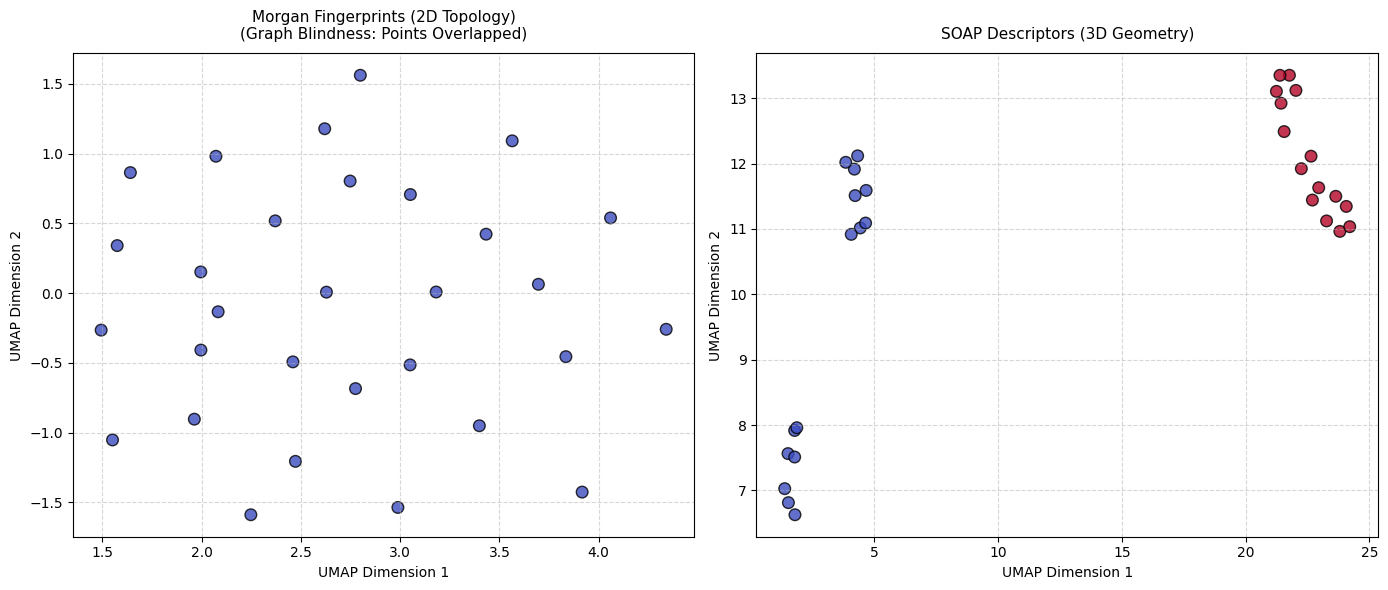


--- Verifying Geometric Twist Conformers ---
Mol 00 | Type: cis   | Dihedral Angle: +0.00°
Mol 01 | Type: trans | Dihedral Angle: +180.00°
Mol 02 | Type: cis   | Dihedral Angle: +0.00°
Mol 03 | Type: trans | Dihedral Angle: -180.00°
Mol 04 | Type: cis   | Dihedral Angle: -0.00°
Mol 05 | Type: trans | Dihedral Angle: +180.00°
Mol 06 | Type: cis   | Dihedral Angle: -0.00°
Mol 07 | Type: trans | Dihedral Angle: -180.00°
Mol 08 | Type: cis   | Dihedral Angle: +0.00°
Mol 09 | Type: trans | Dihedral Angle: +180.00°


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from dscribe.descriptors import SOAP
from ase import Atoms
import umap
from sklearn.cluster import KMeans

# --- 1. DATA GENERATION (Cis vs Trans Isomers) ---
smiles_list = [r"C/C=C\C", "C/C=C/C"] * 15

# We will populate a fresh list with the proper 3D molecules
mols_3d = []
ase_molecules = []

for i, s in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(s)
    mol = Chem.AddHs(mol) # Explicit Hydrogens
    AllChem.EmbedMolecule(mol, randomSeed=i)  # Generate 3D Coordinates
    AllChem.MMFFOptimizeMolecule(mol)         # Energy minimization
    
    # Store the 3D version so we can read its conformer later
    mols_3d.append(mol)
    
    # Map to ASE for SOAP
    positions = mol.GetConformer().GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    ase_molecules.append(Atoms(symbols=symbols, positions=positions))

# --- 2. DESCRIPTOR EXTRACTION ---
morgan_fps = []
for mol in mols_3d:
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    morgan_fps.append(np.array(fp))
morgan_fps = np.array(morgan_fps)

soap_desc = SOAP(
    species=["C", "H"],
    periodic=False,
    r_cut=4.5,
    n_max=5,
    l_max=4,
    average="inner"  # Using your specified 'inner' averaging
)
soap_features = soap_desc.create(ase_molecules)

# --- 3. PROJECTION AND CLUSTERING ---
def run_umap_and_plot(features, title, ax, metric='euclidean'):
    if np.allclose(features, features[0]):
        labels = np.zeros(features.shape[0])
        is_collapsed = True
    else:
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features)
        is_collapsed = False
        
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric=metric, random_state=42)
    embedding = reducer.fit_transform(features)
    
    if is_collapsed or np.var(embedding) < 1e-3:
        embedding += np.random.normal(0, 0.05, embedding.shape)
        title += "\n(Graph Blindness: Points Overlapped)"

    ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=labels, 
        cmap='coolwarm', 
        s=70, 
        edgecolors='k', 
        alpha=0.8
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.grid(True, linestyle='--', alpha=0.5)
    return labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
_ = run_umap_and_plot(morgan_fps, "Morgan Fingerprints (2D Topology)", ax1, metric='jaccard')
soap_cluster_labels = run_umap_and_plot(soap_features, "SOAP Descriptors (3D Geometry)", ax2, metric='euclidean')
plt.tight_layout()
plt.show()

# --- 4. DIHEDRAL GEOMETRY ANALYSIS ---
def get_backbone_dihedral(mol):
    pattern = Chem.MolFromSmarts("[#6]-[#6]=[#6]-[#6]")
    matches = mol.GetSubstructMatches(pattern)
    if not matches:
        return None
    
    atom_indices = matches[0] 
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    if dihedral_deg > 180:
        dihedral_deg -= 360
    return dihedral_deg

print("\n--- Verifying Geometric Twist Conformers ---")
dihedrals = []
# Loop over mols_3d which explicitly contains the 3D coordinate conformers
for idx, mol in enumerate(mols_3d):
    angle = get_backbone_dihedral(mol)
    dihedrals.append(angle)
    
    if idx < 10:
        isomer_type = "cis" if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx] else "trans"
        print(f"Mol {idx:02d} | Type: {isomer_type:<5} | Dihedral Angle: {angle:+.2f}°")

In [35]:
def get_hydrogen_dihedral(mol):
    # Find a terminal hydrogen attached to Carbon 0, and track the path H-C-C=C
    # Pattern: Hydrogen attached to a Carbon, attached to a double-bonded Carbon, attached to a Carbon
    pattern = Chem.MolFromSmarts("[#1]-[#6]-[#6]=[#6]")
    matches = mol.GetSubstructMatches(pattern)
    
    if not matches:
        return None
    
    atom_indices = matches[0] # [H, C, C, C]
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    if dihedral_deg > 180:
        dihedral_deg -= 360
    return dihedral_deg

# Print out the hydrogen angles for the cis molecules
for idx, mol in enumerate(mols_3d):
    if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx]: # Only look at cis
        h_angle = get_hydrogen_dihedral(mol)
        print(f"Mol {idx:02d} (cis) | Hydrogen Dihedral Angle: {h_angle:+.2f}°")

Mol 00 (cis) | Hydrogen Dihedral Angle: +120.74°
Mol 02 (cis) | Hydrogen Dihedral Angle: -120.73°
Mol 04 (cis) | Hydrogen Dihedral Angle: +120.73°
Mol 06 (cis) | Hydrogen Dihedral Angle: -120.74°
Mol 08 (cis) | Hydrogen Dihedral Angle: +0.00°
Mol 10 (cis) | Hydrogen Dihedral Angle: +120.73°
Mol 12 (cis) | Hydrogen Dihedral Angle: +120.73°
Mol 14 (cis) | Hydrogen Dihedral Angle: -120.74°
Mol 16 (cis) | Hydrogen Dihedral Angle: -120.73°
Mol 18 (cis) | Hydrogen Dihedral Angle: +0.00°
Mol 20 (cis) | Hydrogen Dihedral Angle: +0.00°
Mol 22 (cis) | Hydrogen Dihedral Angle: +120.73°
Mol 24 (cis) | Hydrogen Dihedral Angle: -120.73°
Mol 26 (cis) | Hydrogen Dihedral Angle: +120.74°
Mol 28 (cis) | Hydrogen Dihedral Angle: -120.73°


In [ ]:
import pandas as pd
ground_truth = ["cis" if "C\\C" in s or r"C\C" in s else "trans" for s in smiles_list]

df = pd.DataFrame({
    'Actual_Structure': ground_truth,
    'Assigned_Cluster': labels
})

# 4. Print the confusion matrix
print(pd.crosstab(df['Actual_Structure'], df['Assigned_Cluster']))

Assigned_Cluster   0   1
Actual_Structure        
cis                0  15
trans             15   0


In [ ]:
from rdkit.Chem import rdMolTransforms

def get_backbone_dihedral(mol):
    # Match the 4-carbon backbone: C-C=C-C
    # This SMARTS pattern matches the four carbons in order
    pattern = Chem.MolFromSmarts("[#6]-[#6]=[#6]-[#6]")
    matches = mol.GetSubstructMatches(pattern)
    
    if not matches:
        return None
    
    # Get the indices of the 4 backbone carbons
    atom_indices = matches[0] 
    
    # Extract the 3D conformer coordinates
    conformer = mol.GetConformer()
    
    # Calculate dihedral angle in degrees
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    # Standardize output to range [-180, 180]
    if dihedral_deg > 180:
        dihedral_deg -= 360
        
    return dihedral_deg

dihedrals = []
for idx, mol in enumerate(mols):
    angle = get_backbone_dihedral(mol)
    dihedrals.append(angle)
    
    # Print the first few to see the raw values
    if idx < 10:
        isomer_type = "cis" if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx] else "trans"
        print(f"Mol {idx:02d} | Type: {isomer_type:<5} | Dihedral Angle: {angle:+.2f}°")

Mol 00 | Type: cis   | Dihedral Angle: +nan°
Mol 01 | Type: trans | Dihedral Angle: +nan°
Mol 02 | Type: cis   | Dihedral Angle: +nan°
Mol 03 | Type: trans | Dihedral Angle: +nan°
Mol 04 | Type: cis   | Dihedral Angle: +nan°
Mol 05 | Type: trans | Dihedral Angle: +nan°
Mol 06 | Type: cis   | Dihedral Angle: +nan°
Mol 07 | Type: trans | Dihedral Angle: +nan°
Mol 08 | Type: cis   | Dihedral Angle: +nan°
Mol 09 | Type: trans | Dihedral Angle: +nan°


# Hypothesis 2

In [ ]:
ATOMIC_WEIGHTS = {
    1: 1.008,   # Hydrogen
    6: 12.011,  # Carbon
    7: 14.007,  # Nitrogen
    8: 15.999,  # Oxygen
    9: 18.998   # Fluorine
}

def calc_mass_weighted_rg(row):
    """Calculates the mass-weighted Radius of Gyration from coordinates and atomic numbers."""
    coords = np.array(row["coordinates"])
    atomic_nums = row["atomic_numbers"]
    
    # 1. Map atomic numbers to physical masses
    masses = np.array([ATOMIC_WEIGHTS[z] for z in atomic_nums])
    total_mass = np.sum(masses)
    
    # 2. Calculate the Center of Mass (COM)
    com = np.sum(coords * masses[:, np.newaxis], axis=0) / total_mass
    
    # 3. Calculate squared distances of each atom from the COM
    sq_distances = np.sum((coords - com)**2, axis=1)
    
    # 4. Calculate the mass-weighted radius of gyration
    rg = np.sqrt(np.sum(masses * sq_distances) / total_mass)
    
    return float(rg)

# Apply the function across the DataFrame using Polars' struct mapping
df = df.with_columns(
    pl.struct(["coordinates", "atomic_numbers"])
    .map_elements(calc_mass_weighted_rg, return_dtype=pl.Float64)
    .alias("radius_of_gyration")
)

# Hyphotesis 1

In [ ]:
df_iso = get_isomers(df, pure_carbon = True, n=906)

2026-05-19 10:30:57.998 | INFO     | src.helper_functions:get_isomers:83 - Selected most frequent QM9 isomer group: formula=C9H14, available=906, returned=906.


In [ ]:
soap_matrices = df_iso['soap_matrix'].to_list()

# 2. Initialize the REMatch Kernel
# You MUST define the base metric and the entropy regularization parameter.
kernel = REMatchKernel(
    metric="linear",  # Base kernel to compare individual atomic environments
    alpha=0.1         # Entropy regularization (Sinkhorn parameter)
)

# 3. Compute the N x N Kernel Similarity Matrix
print("Computing REMatch kernel matrix...")
kernel_matrix = kernel.create(soap_matrices)

# 4. Convert Kernel Matrix to Distance Matrix (Your perfect code)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

# Eliminate floating point artifacts on diagonals and force strict symmetry
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0

Computing REMatch kernel matrix...


In [ ]:
rg_values = df_iso["radius_of_gyration"].to_numpy()

print("Computing UMAP projection...")
reducer = UMAP(n_neighbors=15, metric='precomputed', random_state=42)
umap_coords = reducer.fit_transform(dist_matrix)

plot_df = pl.DataFrame({
    "UMAP_1": umap_coords[:, 0],
    "UMAP_2": umap_coords[:, 1],
    "Radius_of_Gyration": rg_values
}).to_pandas()

Computing UMAP projection...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_33801/105005104.py:18: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label('Radius of Gyration (Å)\nFolded  $\longrightarrow$  Extended', fontsize=12, fontweight='bold', labelpad=15)


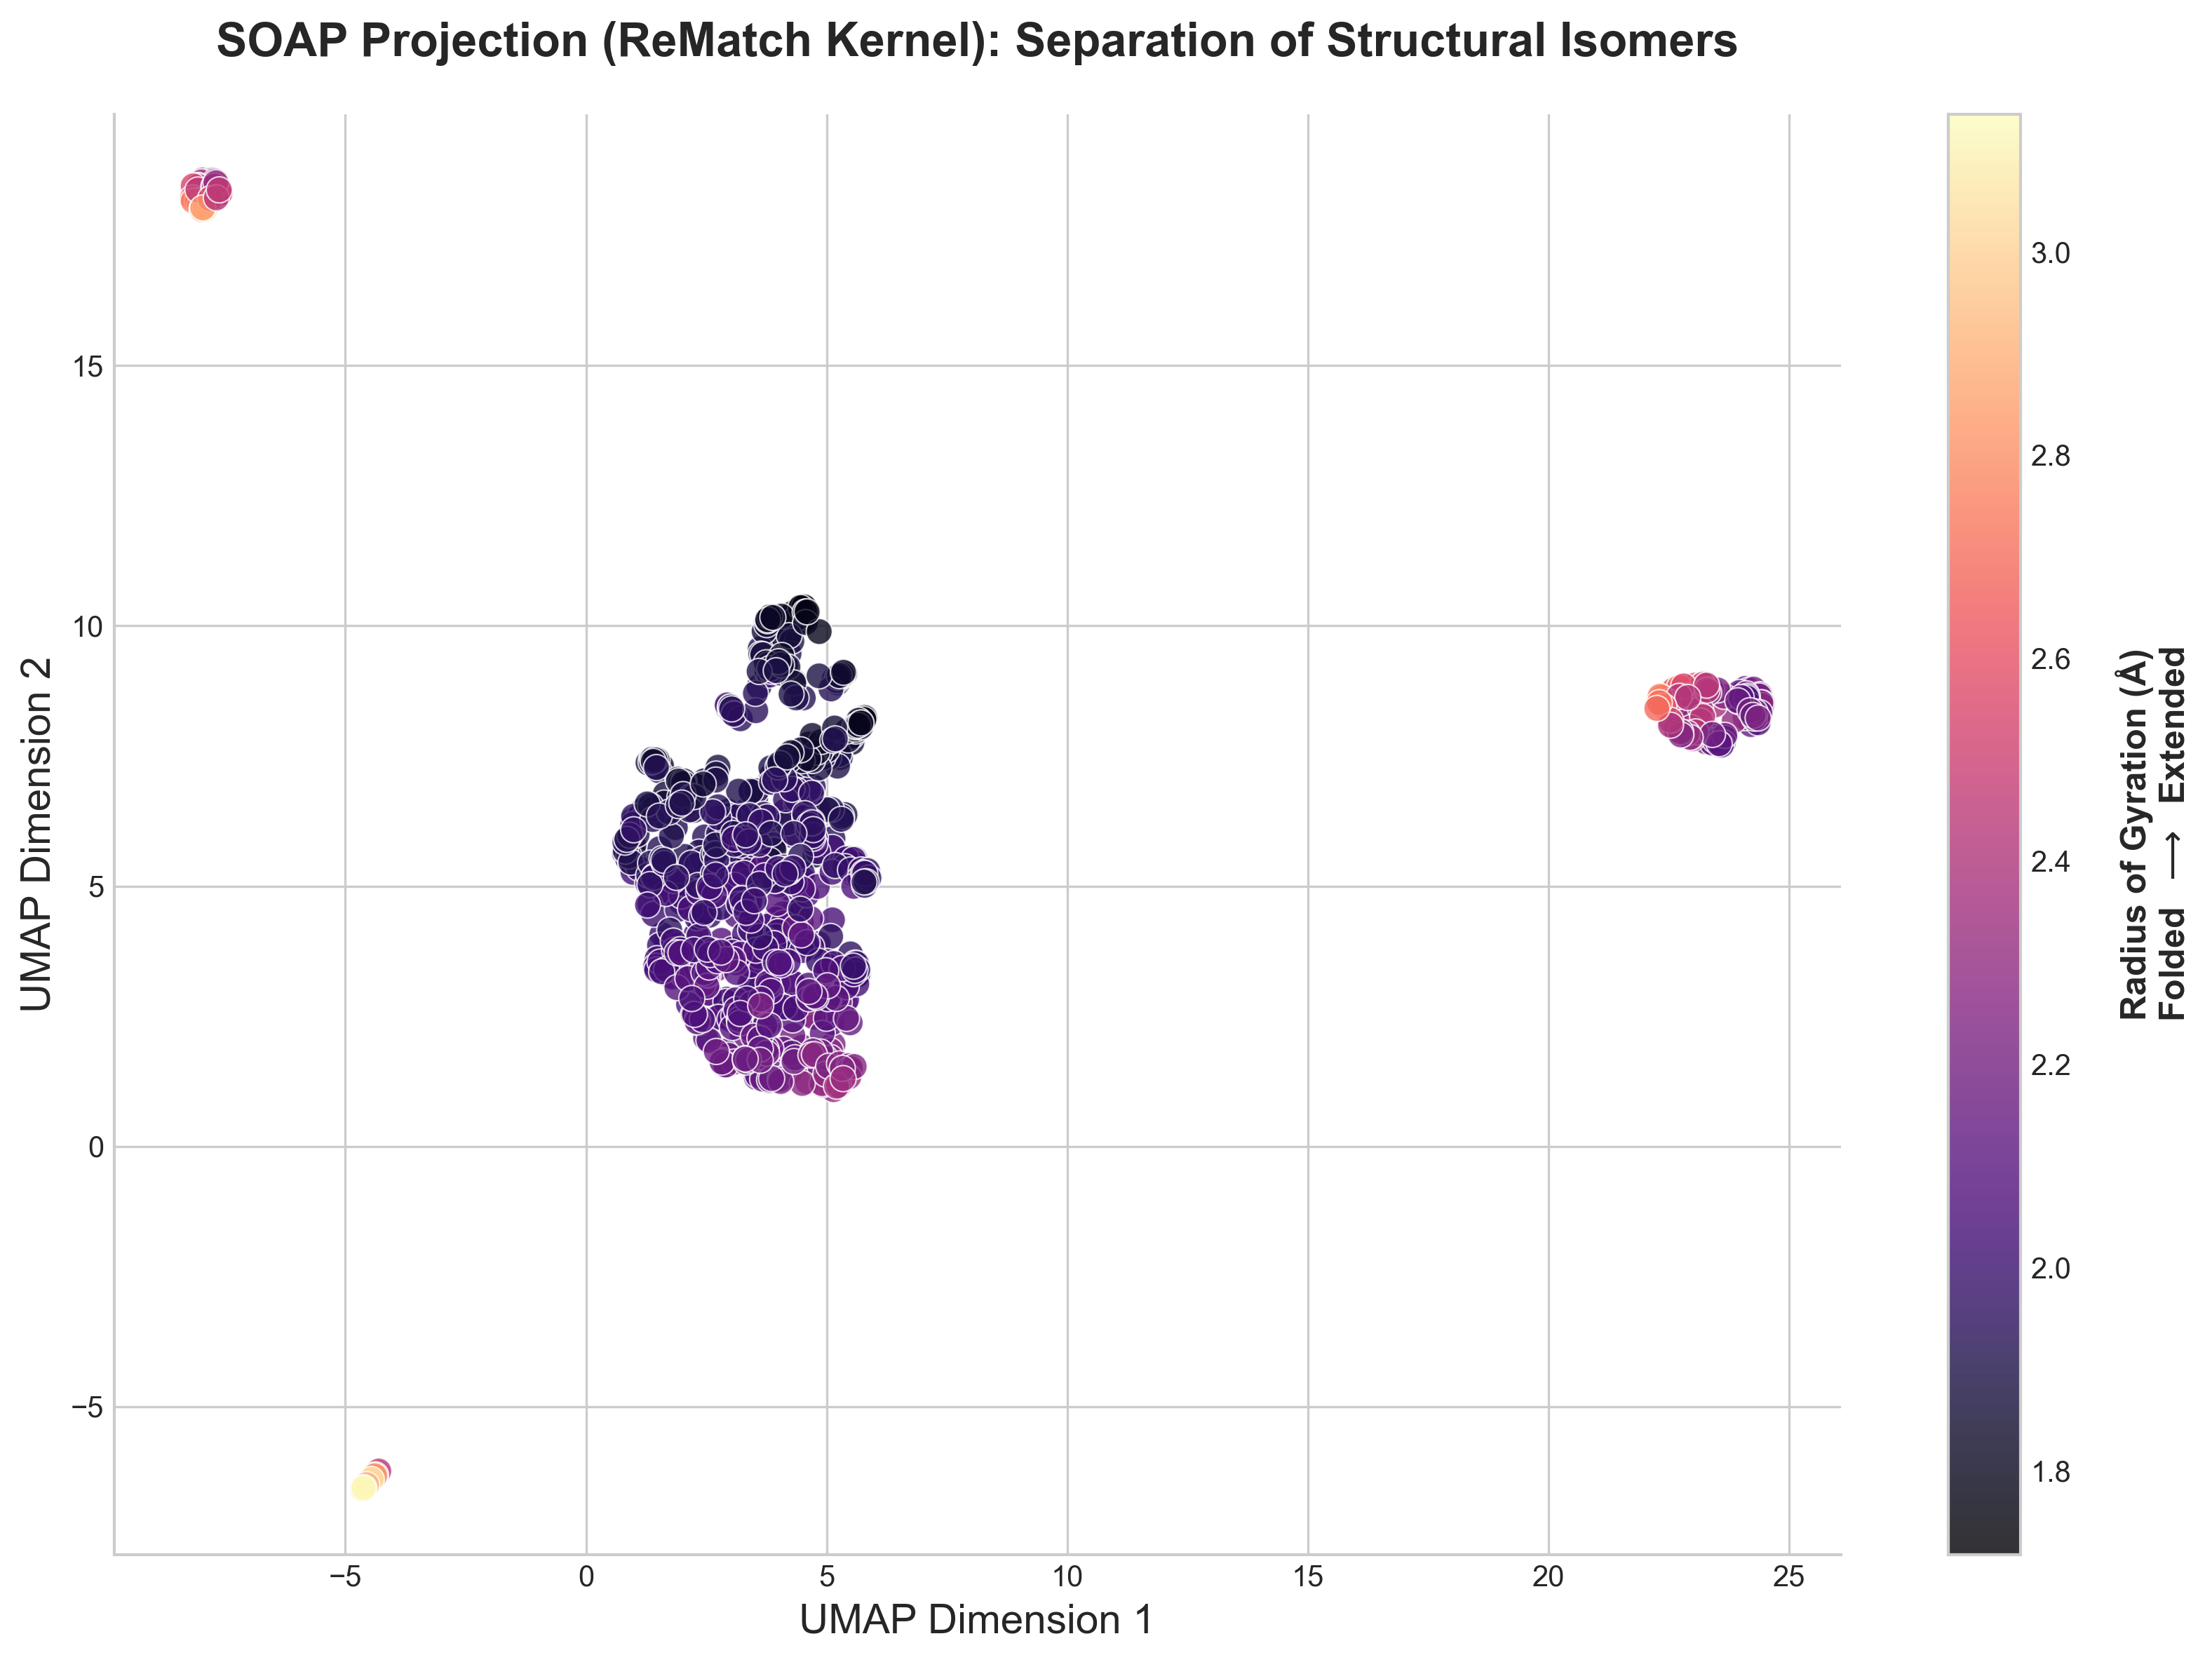

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# Use ax.scatter directly, as it handles continuous colorbars better than sns.scatterplot
scatter = ax.scatter(
    x=plot_df["UMAP_1"], 
    y=plot_df["UMAP_2"], 
    c=plot_df["Radius_of_Gyration"], 
    cmap="magma",   # 'magma' or 'viridis' are ideal for continuous physical values
    s=80,           # Marker size
    alpha=0.8,      # Transparency to reveal density
    edgecolor='w',  # White border for crisp edges
    linewidth=0.5
)

# 5. Add the Colorbar and Labels
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Radius of Gyration (Å)\nFolded  $\longrightarrow$  Extended', fontsize=12, fontweight='bold', labelpad=15)

ax.set_title("SOAP Projection (ReMatch Kernel): Separation of Structural Isomers", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=14, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=14, fontweight='medium')

# Clean up axes
sns.despine(fig)
plt.tight_layout()

plt.show()

In [ ]:
create_chemiscope_viewer(df_iso, dist_matrix, labels=[i for i in range(len(df_iso))], reduction_method='UMAP')

2026-05-19 10:49:40.649 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-19 10:49:40.693 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-19 10:50:02.036 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-19 10:50:02.805 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

# Hypothesis 2
- Molecules with 3 membered rings will be strained and have a different SOAP than molecules with a 6 membered ring.

In [ ]:
def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles (rings with O, N, F).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    # Get ring information
    ring_info = mol.GetRingInfo().AtomRings()
    
    # Reject acyclic molecules
    if not ring_info:
        return "Acyclic"
        
    # Check if ALL rings are pure Carbon (Atomic Number == 6)
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle" # Reject if the ring contains O, N, F, etc.
                
    # Extract unique ring sizes
    sizes = set(len(ring) for ring in ring_info)
    
    # Return valid pure carbocycles
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"

# 1. Apply the strict function
print("Categorizing rings and enforcing carbocycles using RDKit...")
df = df.with_columns(
    pl.col("smiles")
    .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
    .alias("ring_category")
)

# 1. Start with the fully categorized dataset (NO heavy atom filter yet)
df_3_rings_all = df.filter(pl.col("ring_category") == "3-ring")
df_6_rings_all = df.filter(pl.col("ring_category") == "6-ring")

# 2. Count the occurrences of each formula in both groups
counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})

# 3. Join the counts to find formulas that exist in BOTH groups
formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

# 4. Calculate the bottleneck (the maximum possible balanced sample size)
# The max size is constrained by whichever group has fewer molecules
formula_overlap = formula_overlap.with_columns(
    pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
).sort("max_balanced_size", descending=True)

# Let's see the top 5 formulas in the whole dataset for this experiment
print("Top 5 optimal formulas for the strain experiment:")
print(formula_overlap.head(10))

# 5. Extract the absolute best formula
if formula_overlap.height == 0:
    raise ValueError("No shared formulas found in the dataset!")

best_row = formula_overlap.row(0, named=True)
best_formula = best_row["formula"]
max_size = best_row["max_balanced_size"]

print(f"\nStrict Control Triggered: Restricting entire experiment to {best_formula}")
print(f"This allows for a perfectly balanced dataset of {max_size} vs {max_size} molecules.")

# 6. Create the final perfectly balanced dataset
df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)

df_strain_experiment = pl.concat([df_3_sampled, df_6_sampled])
print(f"Final experimental dataset shape: {df_strain_experiment.height} molecules.")

Categorizing rings and enforcing carbocycles using RDKit...
Top 5 optimal formulas for the strain experiment:
shape: (10, 4)
┌─────────┬─────────┬─────────┬───────────────────┐
│ formula ┆ count_3 ┆ count_6 ┆ max_balanced_size │
│ ---     ┆ ---     ┆ ---     ┆ ---               │
│ str     ┆ u32     ┆ u32     ┆ u32               │
╞═════════╪═════════╪═════════╪═══════════════════╡
│ C9H16   ┆ 29      ┆ 37      ┆ 29                │
│ C9H12   ┆ 16      ┆ 25      ┆ 16                │
│ C9H18   ┆ 66      ┆ 10      ┆ 10                │
│ C8H14   ┆ 8       ┆ 10      ┆ 8                 │
│ C9H14   ┆ 96      ┆ 7       ┆ 7                 │
│ C8H16   ┆ 25      ┆ 5       ┆ 5                 │
│ C8H12   ┆ 33      ┆ 2       ┆ 2                 │
│ C8H10   ┆ 2       ┆ 6       ┆ 2                 │
│ C7H12   ┆ 3       ┆ 2       ┆ 2                 │
│ C6H12   ┆ 4       ┆ 1       ┆ 1                 │
└─────────┴─────────┴─────────┴───────────────────┘

Strict Control Triggered: Restricting enti

In [ ]:
soap_matrices = df_strain_experiment['soap_matrix'].to_list()

# 2. Initialize the REMatch Kernel
# You MUST define the base metric and the entropy regularization parameter.
kernel = REMatchKernel(
    metric="linear",  # Base kernel to compare individual atomic environments
    alpha=0.001        # Entropy regularization (Sinkhorn parameter)
)

df_strain_experiment = df_strain_experiment.with_columns(
    ring_labels = pl.when(pl.col("ring_category") == "3-ring")
                    .then(3)
                    .otherwise(6)
)

# 3. Compute the N x N Kernel Similarity Matrix
print("Computing REMatch kernel matrix...")
kernel_matrix = kernel.create(soap_matrices)

# 4. Convert Kernel Matrix to Distance Matrix (Your perfect code)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

# Eliminate floating point artifacts on diagonals and force strict symmetry
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0

Computing REMatch kernel matrix...


In [ ]:
create_chemiscope_viewer(df_strain_experiment, dist_matrix, labels=df_strain_experiment['ring_labels'].to_list(), reduction_method='UMAP')

2026-05-19 10:55:39.496 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-19 10:55:39.497 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-19 10:55:39.756 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 5
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-19 10:55:39.786 | INFO     | src.helper_f

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computing UMAP projection from precomputed distance matrix...
Saved high-res plot to soap_strain_hypothesis.png


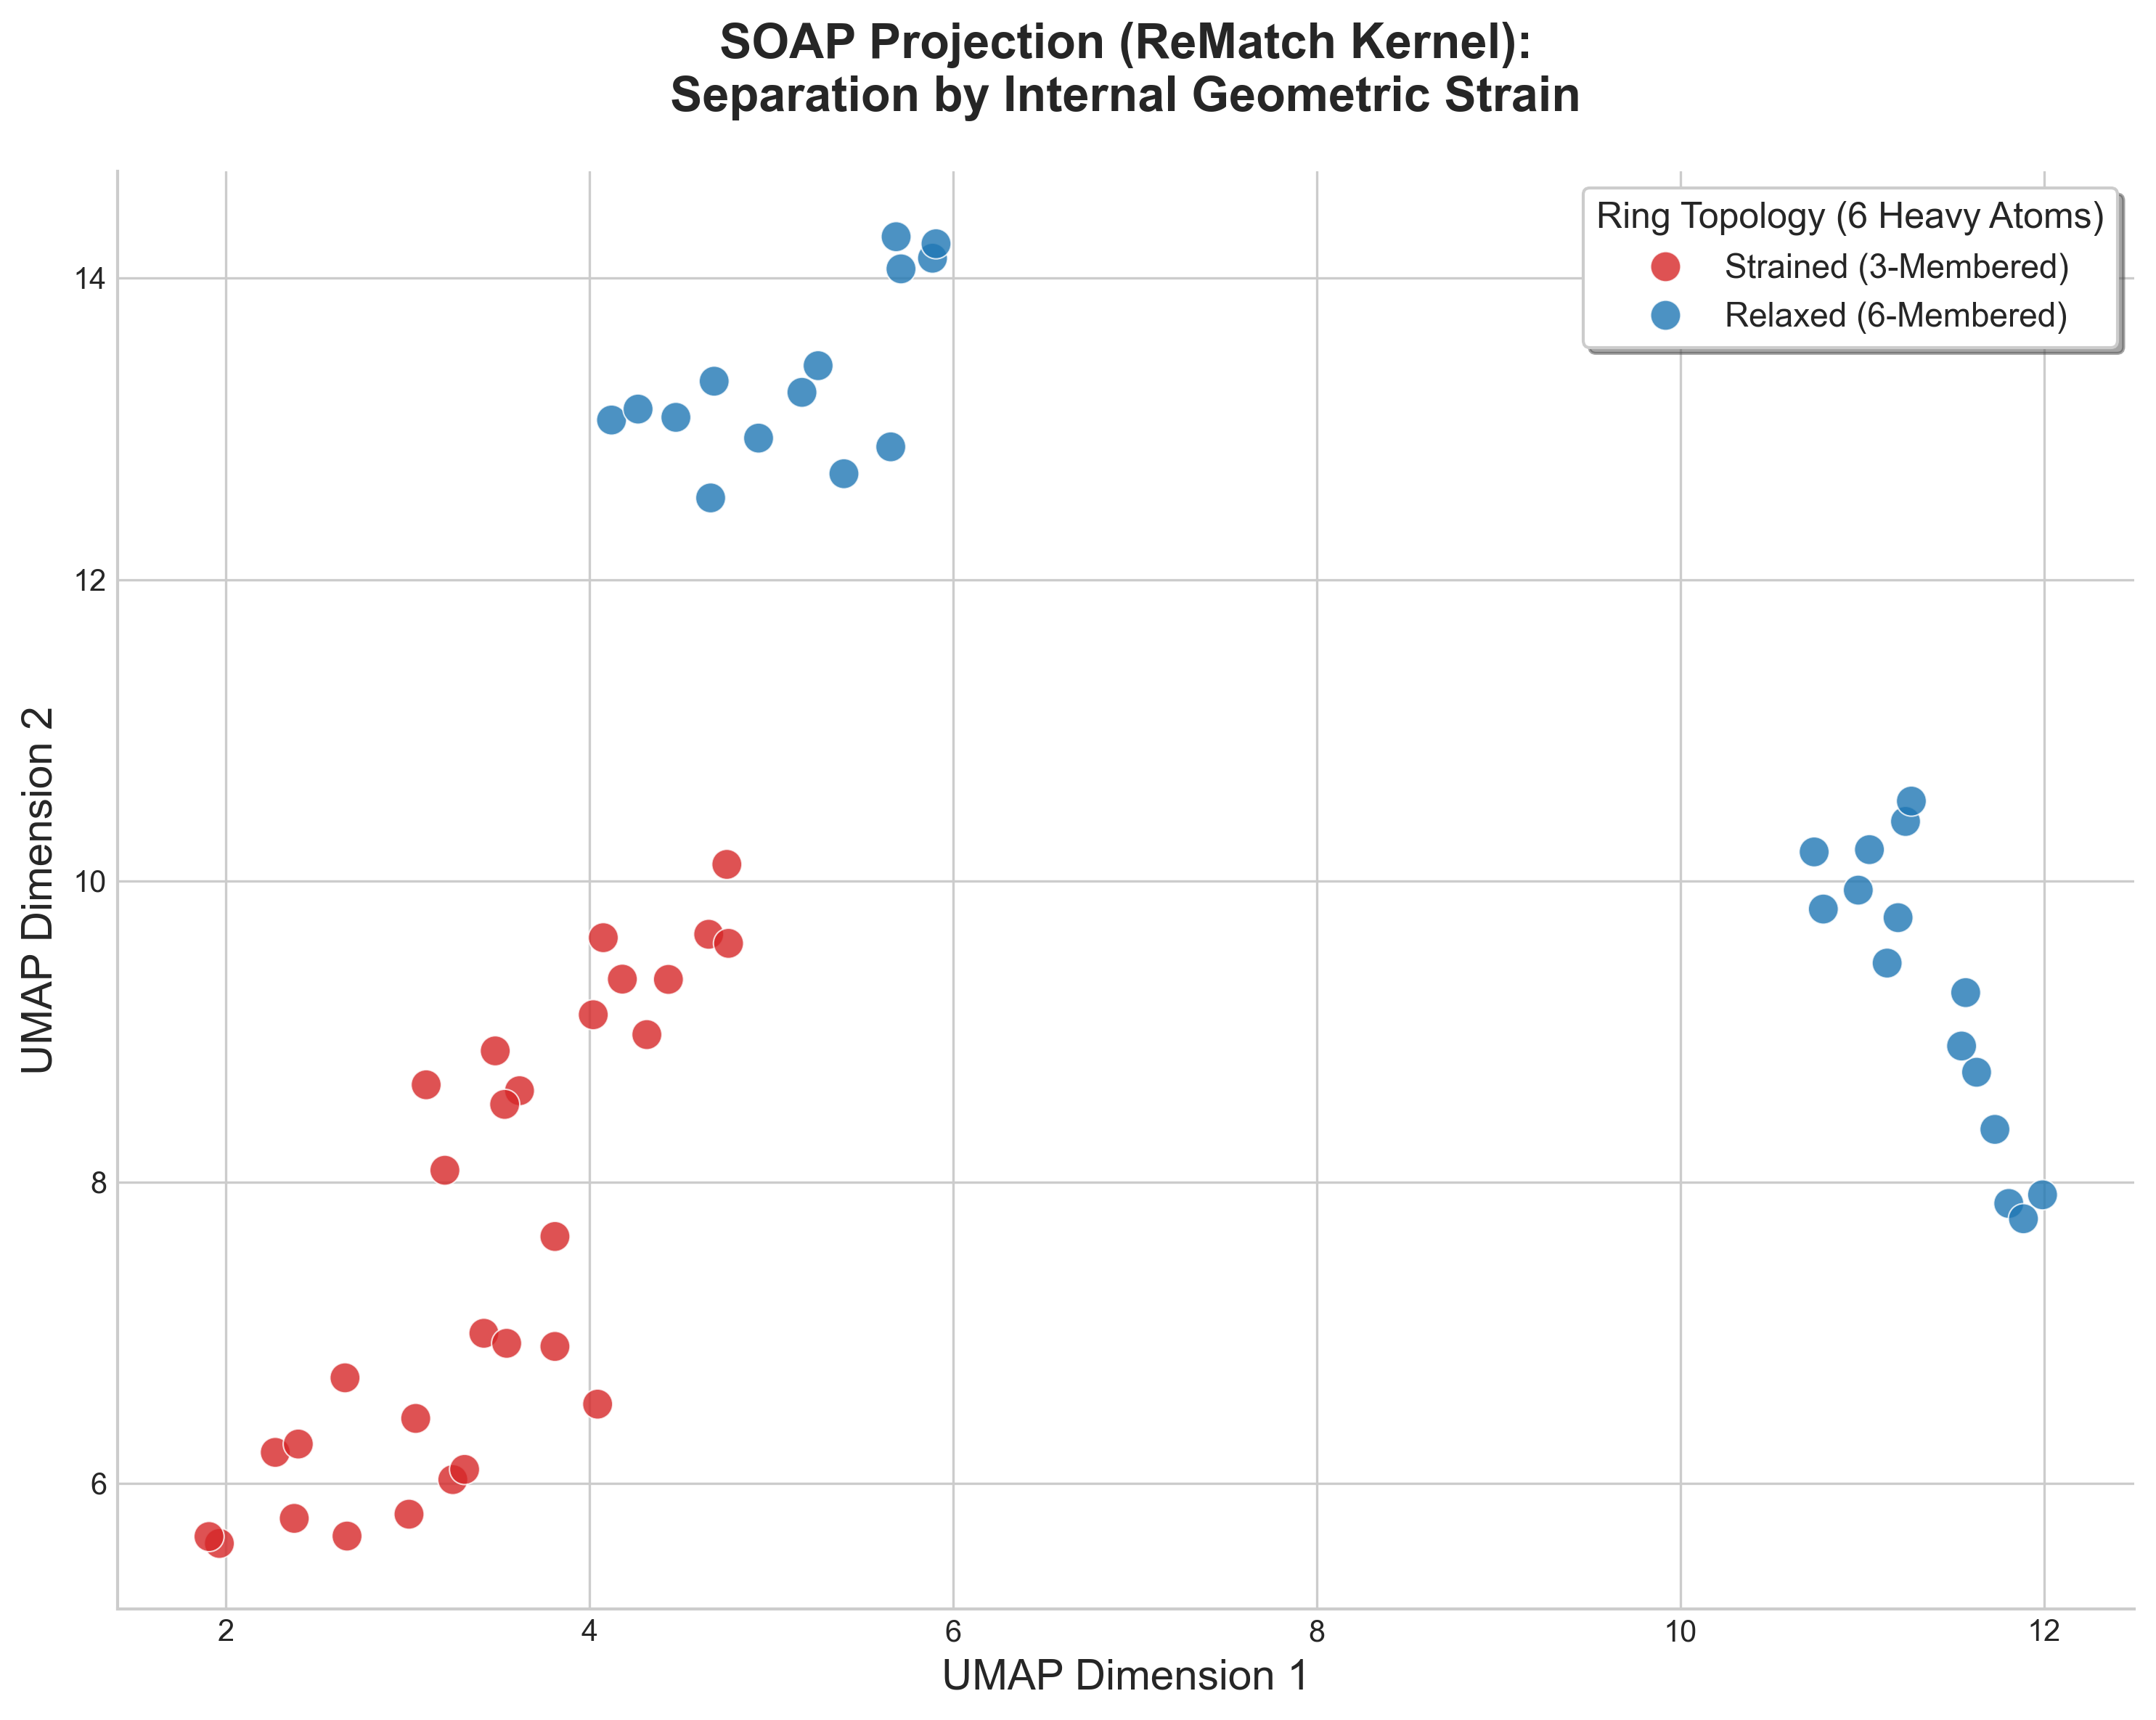

In [ ]:

# 1. Compute the UMAP Projection from the custom distance matrix
print("Computing UMAP projection from precomputed distance matrix...")
reducer = UMAP(n_neighbors=5, metric='precomputed', random_state=42)
umap_coords = reducer.fit_transform(dist_matrix)

# 2. Extract labels and prepare for plotting
# We map the 3 and 6 back to descriptive strings for a clean legend
ring_labels_raw = df_strain_experiment["ring_labels"].to_numpy()
legend_labels = ["Strained (3-Membered)" if val == 3 else "Relaxed (6-Membered)" for val in ring_labels_raw]

# 3. Generate the Figure
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Use a custom color palette with high contrast for the two categories
# Deep red/orange for "Strained" and cool blue for "Relaxed"
palette = {
    "Strained (3-Membered)": "#d62728", 
    "Relaxed (6-Membered)": "#1f77b4"
}

sns.scatterplot(
    x=umap_coords[:, 0], 
    y=umap_coords[:, 1], 
    hue=legend_labels,
    palette=palette,
    s=100,          # Large markers for visibility
    alpha=0.8,      # Slight transparency
    edgecolor='w',  # White border for crispness
    linewidth=0.5,
    ax=ax
)

# 4. Styling and Labels
ax.set_title("SOAP Projection (ReMatch Kernel):\nSeparation by Internal Geometric Strain", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=14, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=14, fontweight='medium')

# Clean up the legend
ax.legend(
    title="Ring Topology (6 Heavy Atoms)", 
    title_fontsize=12,
    fontsize=11,
    loc='best', 
    frameon=True,
    shadow=True
)

# Remove top and right spines
sns.despine(fig)
plt.tight_layout()

# 5. Save and Show
plt.savefig("soap_strain_hypothesis.png", format='png', dpi=300, bbox_inches='tight')
print("Saved high-res plot to soap_strain_hypothesis.png")
plt.show()